<a href="https://colab.research.google.com/github/mf2056/F20AA/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import pandas as pd
vad_df = pd.read_csv('final_dataset (1).csv')

# Cont of the ignored part in DA notebook

In [55]:
from sklearn.model_selection import train_test_split

X = vad_df["text"]
y = vad_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=25,
    stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

label
positive    1750
negative    1198
neutral      556
Name: count, dtype: int64
label
positive    438
negative    299
neutral     139
Name: count, dtype: int64


In [56]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [58]:

import re
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text

lemmatizer = WordNetLemmatizer()

# Custom stopwords (keep negations)
stop_words = text.ENGLISH_STOP_WORDS
negations = {"no", "nor", "not"}
custom_stopwords = list(stop_words.difference(negations))

def simple_analyzer(doc):
    doc = doc.lower()                     # normalization
    doc = re.sub(r"[^a-z\s]", "", doc)    # remove punctuation
    tokens = doc.split()                  # tokenization

    lemmas = []
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        if lemma not in custom_stopwords:
            lemmas.append(lemma)

    bigrams = []
    for i in range(len(lemmas) - 1):
        bigrams.append(lemmas[i] + "_" + lemmas[i+1])

    return lemmas + bigrams



vectorizer = TfidfVectorizer(
    analyzer=simple_analyzer,

    # lowercase=True,                    # normalization
    # token_pattern=r"\b[a-zA-Z]+\b",     # tokenization (only words, no punctuation)
    # stop_words=custom_stopwords,       # remove stopwords but keep negations
    # ngram_range=(1,2),
    # min_df=2
)



X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

lem_df = vectorizer.transform(vad_df["text"])

# lem_df = vectorizer.transform(vad_df["text"])

# X_train_vec = vectorizer.fit_transform(X_train)
# X_test_vec = vectorizer.transform(X_test)

In [60]:
print(lem_df.shape)

(4380, 60248)


In [59]:
import pandas as pd

# Convert sparse matrix to dense DataFrame
tfidf_df = pd.DataFrame(
    lem_df.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Add label column (replace "label" with your actual column name)
tfidf_df["label"] = vad_df["label"].values

# Save to CSV
tfidf_df.to_csv("lem_tfidf_dataset.csv", index=False)

KeyboardInterrupt: 

In [ ]:
from google.colab import files
files.download("lem_tfidf_dataset.csv")

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text

# Get default English stopwords
custom_stopwords = set(text.ENGLISH_STOP_WORDS)

# Remove negations from stopwords
negations = {"no", "not", "nor"}
custom_stopwords = list(custom_stopwords - negations)

vectorizer = TfidfVectorizer(
    lowercase=True,                 # lowercasing
    strip_accents='unicode',        # unicode normalization
    token_pattern=r"\b[a-zA-Z]+\b",  # tokenization (words only, removes punctuation)
    ngram_range=(1, 2) ,             # bigrams only
    # stop_words=custom_stopwords
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ML models

In [47]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
nb_pred = nb.predict(X_test_vec)


from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_vec, y_train)
lr_pred = lr.predict(X_test_vec)


from sklearn.svm import LinearSVC

svm = LinearSVC( class_weight="balanced")
svm.fit(X_train_vec, y_train)
svm_pred = svm.predict(X_test_vec)


from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier( class_weight="balanced", random_state=30)
dt.fit(X_train_vec, y_train)
dt_pred = dt.predict(X_test_vec)

from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print(classification_report(y_test, y_pred))

evaluate(y_test, nb_pred, "Naive Bayes")
evaluate(y_test, lr_pred, "Logistic Regression")
evaluate(y_test, svm_pred, "Linear SVM")
evaluate(y_test, dt_pred, "Decision tree")


Naive Bayes
Accuracy: 0.5376712328767124
Macro F1: 0.3011547026009504
              precision    recall  f1-score   support

    negative       0.86      0.13      0.22       299
     neutral       0.00      0.00      0.00       139
    positive       0.52      0.99      0.68       438

    accuracy                           0.54       876
   macro avg       0.46      0.37      0.30       876
weighted avg       0.55      0.54      0.42       876


Logistic Regression
Accuracy: 0.6084474885844748
Macro F1: 0.5502255097003472
              precision    recall  f1-score   support

    negative       0.56      0.71      0.63       299
     neutral       0.38      0.32      0.35       139
    positive       0.73      0.63      0.68       438

    accuracy                           0.61       876
   macro avg       0.56      0.55      0.55       876
weighted avg       0.62      0.61      0.61       876


Linear SVM
Accuracy: 0.639269406392694
Macro F1: 0.5453853317018679
              preci

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Cross validation

In [52]:


from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# # Get default English stopwords
# custom_stopwords = set(text.ENGLISH_STOP_WORDS)

# # Remove negations from stopwords
# negations = {"no", "not", "nor"}
# custom_stopwords = list(custom_stopwords - negations)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer=simple_analyzer,
        # # min_df=2
        # lowercase=True,
        # strip_accents='unicode',
        # token_pattern=r"\b[a-zA-Z]+\b",
        # ngram_range=(2, 2),
        # stop_words = custom_stopwords
    )),
    ("clf", LinearSVC(
        # max_iter=1000,
        class_weight="balanced"
    ))
])

scores_f1 = cross_val_score(
    pipeline,
    vad_df["text"],
    vad_df["label"],
    cv=5,
    scoring="f1_macro"
)

scores_acc = cross_val_score(
    pipeline,
    vad_df["text"],
    vad_df["label"],
    cv=5,
    scoring="accuracy"
)

print("Cross-val Accuracy:", scores_acc)
print("Mean Accuracy:", scores_acc.mean())

print("Cross-val Macro F1:", scores_f1)
print("Mean Macro F1:", scores_f1.mean())


Cross-val Accuracy: [0.61187215 0.5913242  0.59018265 0.59474886 0.62328767]
Mean Accuracy: 0.602283105022831
Cross-val Macro F1: [0.43688133 0.49699122 0.50615793 0.53574168 0.56954244]
Mean Macro F1: 0.5090629197899446


In [ ]:
Macro_F1 = pd.DataFrame({
    "N-gram": ["lowercasing + stopwords + (1-2) + mid_df=2","(1-2) + stopwords", "(1-3)", "(1-1)"],

    "Naive Bayes": [0.25, 0.24, 0.22, 0.24],

    "Logistic Regression": [0.43, 0.44, 0.39, 0.47],

    "Linear SVM": [0.45, 0.42, 0.39, 0.45]
})

Macro_F1

,N-gram,Naive Bayes,Logistic Regression,Linear SVM
0,lowercasing + stopwords + (1-2) + mid_df=2,0.25,0.43,0.45
1,(1-2) + stopwords,0.24,0.44,0.42
2,(1-3),0.22,0.39,0.39
3,(1-1),0.24,0.47,0.45


In [ ]:
import pandas as pd

Accuracy = pd.DataFrame({
    "N-gram": ["(1-2) + stopwords", "(1-2)", "(1-3)", "(1-1)"],

    "Naive Bayes": [0.48, 0.47, 0.46, 0.47],

    "Logistic Regression": [0.50, 0.54, 0.52, 0.55],

    "Linear SVM": [0.54, 0.53, 0.51, 0.51]
})
Accuracy

,N-gram,Naive Bayes,Logistic Regression,Linear SVM
0,(1-2) + stopwords,0.48,0.50,0.54
1,(1-2),0.47,0.54,0.53
2,(1-3),0.46,0.52,0.51
3,(1-1),0.47,0.55,0.51


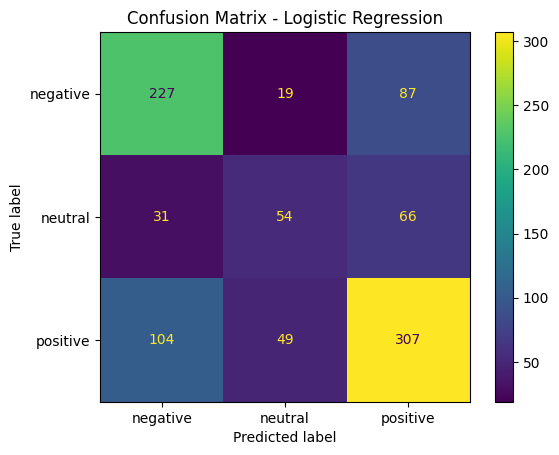

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(vad_df["Label"], y_pred)
pd.DataFrame(cm,
             index=["neg","neu","pos"],
             columns=["neg","neu","pos"])

,neg,neu,pos
neg,761,194,283
neu,130,289,130
pos,302,232,1064


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

y_pred = cross_val_predict(pipeline, vad_df["text"], vad_df["Label"], cv=5)

print(classification_report(vad_df["Label"], y_pred))

              precision    recall  f1-score   support

    negative       0.63      0.61      0.62      1238
     neutral       0.49      0.45      0.47       549
    positive       0.69      0.72      0.71      1598

    accuracy                           0.64      3385
   macro avg       0.60      0.59      0.60      3385
weighted avg       0.63      0.64      0.63      3385



In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

dummy = DummyClassifier(strategy="most_frequent")

dummy_f1 = cross_val_score(
    dummy,
    vad_df["text"],
    vad_df["Label"],
    cv=5,
    scoring="f1_macro"
)

print("Baseline Macro F1:", dummy_f1.mean())

Baseline Macro F1: 0.21379345533253039


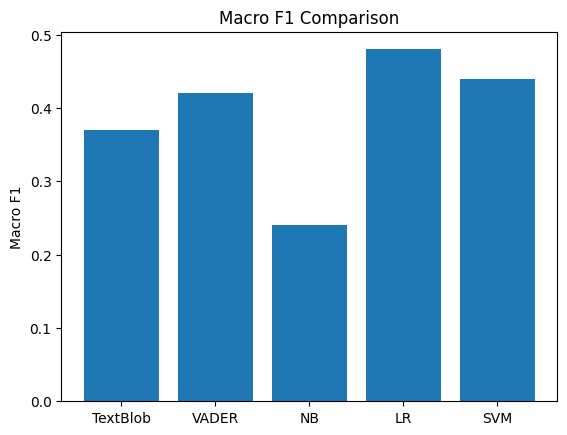

In [ ]:
models = ["TextBlob", "VADER", "NB", "LR", "SVM"]
f1_scores = [0.37, 0.42, 0.24, 0.48, 0.44]

plt.bar(models, f1_scores)
plt.title("Macro F1 Comparison")
plt.ylabel("Macro F1")
plt.show()

In [ ]:
errors = pd.DataFrame({
    "text": X_test,
    "true_label": y_test,
    "predicted_label": lr_pred
})

misclassified = errors[errors["true_label"] != errors["predicted_label"]]
misclassified.sample(10, random_state=25)

,text,true_label,predicted_label
302,$24/hr for a warehouse job? I could understan...,neutral,negative
247,"I had my first day ride along on the 17th, qui...",negative,neutral
175,I hope he pays for disrespecting his workers l...,negative,neutral
502,Love the show and I am a Hispanic who listens ...,negative,positive
154,"Lol. Yall are irrelevant as all hell, they mak...",neutral,negative
386,HAHAHAHAHA omg i just watched a liberal chick ...,negative,neutral
426,I must be lucky. I always use the bathroom and...,positive,negative
418,Ty! ❤ I'm a postal worker .. \nI definitely ap...,positive,neutral
284,You can clock in 5 before and after your shift...,neutral,positive
563,I don't mind paying the membership. Where I li...,positive,negative


#table for pipelines

In [ ]:
feature_names = vectorizer.get_feature_names_out()
coefs = lr.coef_

for i, label in enumerate(lr.classes_):
    top10 = coefs[i].argsort()[-10:]
    print(f"\nTop words for {label}:")
    print([feature_names[j] for j in top10])


Top words for negative:
['better', 'stop', 'employees', 'time', 'good', 'for', 'more', 'was', 'they', 'no']

Top words for neutral:
['office', 'location', 'are', 'put', 'tell', 'am', 'fedex', 'do', 'paid', 'be']

Top words for positive:
['nigga', 'years', 'work', 'keep', 'great', 'and', 'thank', 'job', 'it', 'people']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,1)
    )),
    ("clf", LogisticRegression(
        C=5,
        max_iter=1000,
        class_weight="balanced"
    ))
])

#print out f1 and accuracy for this also then train on all manual data

# Train on ALL manual data
final_pipeline.fit(df["text"], df["manual_label"])

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf',
                 LogisticRegression(C=5, class_weight='balanced',
                                    max_iter=1000))])

In [ ]:
full_df = pd.read_csv("amazon_tb_v.csv")

In [ ]:
full_df["ml_label"] = final_pipeline.predict(full_df["text"])

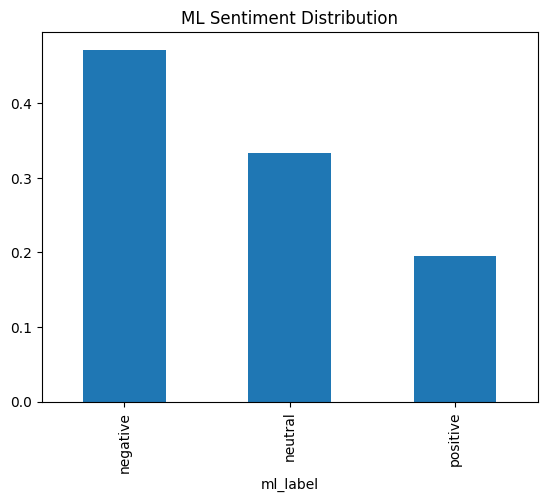

In [ ]:
import matplotlib.pyplot as plt

full_df["ml_label"].value_counts(normalize=True).plot(kind="bar")
plt.title("ML Sentiment Distribution")
plt.show()

# print top count stuff

In [ ]:
full_df["tb_label"].value_counts()

,count
tb_label,
positive,1470
neutral,1101
negative,814


In [ ]:
full_df["vader_label"].value_counts()

,count
vader_label,
positive,1777
negative,1204
neutral,404


In [ ]:
full_df["vader_label"].value_counts(normalize=True)

,proportion
vader_label,
positive,0.524963
negative,0.355687
neutral,0.119350


In [ ]:
full_df["tb_label"].value_counts(normalize=True)

,proportion
tb_label,
positive,0.434269
neutral,0.325258
negative,0.240473


In [ ]:
full_df["ml_label"].value_counts(normalize=True)

,proportion
ml_label,
negative,0.471787
neutral,0.332939
positive,0.195273


In [ ]:
df["manual_label"].value_counts(normalize=True)

,proportion
manual_label,
negative,0.458333
neutral,0.345000
positive,0.196667


In [ ]:
full_df.head()

,text,vader_label,tb_label,ml_label
0,I'm suspended for having my Medical Marijuana ...,negative,neutral,negative
1,Amazon employees are over worked with mandator...,negative,neutral,negative
2,DONT BELIEVE THE HYPE! IF MANAGEMENT DONT GIVE...,neutral,neutral,negative
3,Correct me if I am wrong. From all the people ...,positive,neutral,neutral
4,Amazon treats its workers like dirt and then a...,positive,positive,negative


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving train_dataset.csv to train_dataset.csv


In [ ]:
vad_df = pd.read_csv('train_dataset.csv')

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,1))),
    ("clf", LogisticRegression(C = 1.0, max_iter=1000, class_weight="balanced"))
])

scores = cross_val_score(
    pipeline,
    vad_df["text"],
    vad_df["Label"],
    cv=5,
    scoring="f1_macro"
)

accuracy = cross_val_score(
    pipeline,
    vad_df["text"],
    vad_df["Label"],
    cv=5,
    scoring="accuracy"
)

print("Cross-val Accuracy:", accuracy)
print("Mean Accuracy:", accuracy.mean())
print("Cross-val Macro F1 scores:", scores)
print("Mean Macro F1:", scores.mean())

Cross-val Accuracy: [0.61447563 0.61890694 0.59379616 0.61004431 0.62924668]
Mean Accuracy: 0.6132939438700148
Cross-val Macro F1 scores: [0.58119086 0.59406764 0.57139413 0.58514801 0.59812747]
Mean Macro F1: 0.5859856191079089


Lowercasing (reduce case variance)

Punctuation removal (remove noisy symbols)

Normalization (clean non-text noise)

Tokenization (split into tokens)

Stopword negation (preserve sentiment polarity)

Lemmatization (reduce to base form)

These models were selected based on their established effectiveness in text classification tasks, particularly with sparse TF-IDF representations ([Kowsari et al., 2019](https://arxiv.org/pdf/1904.08067#page=20.84)).